# Assignment 6: More Matplotlib

## Problem 1: Line plots

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [2]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [6]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt

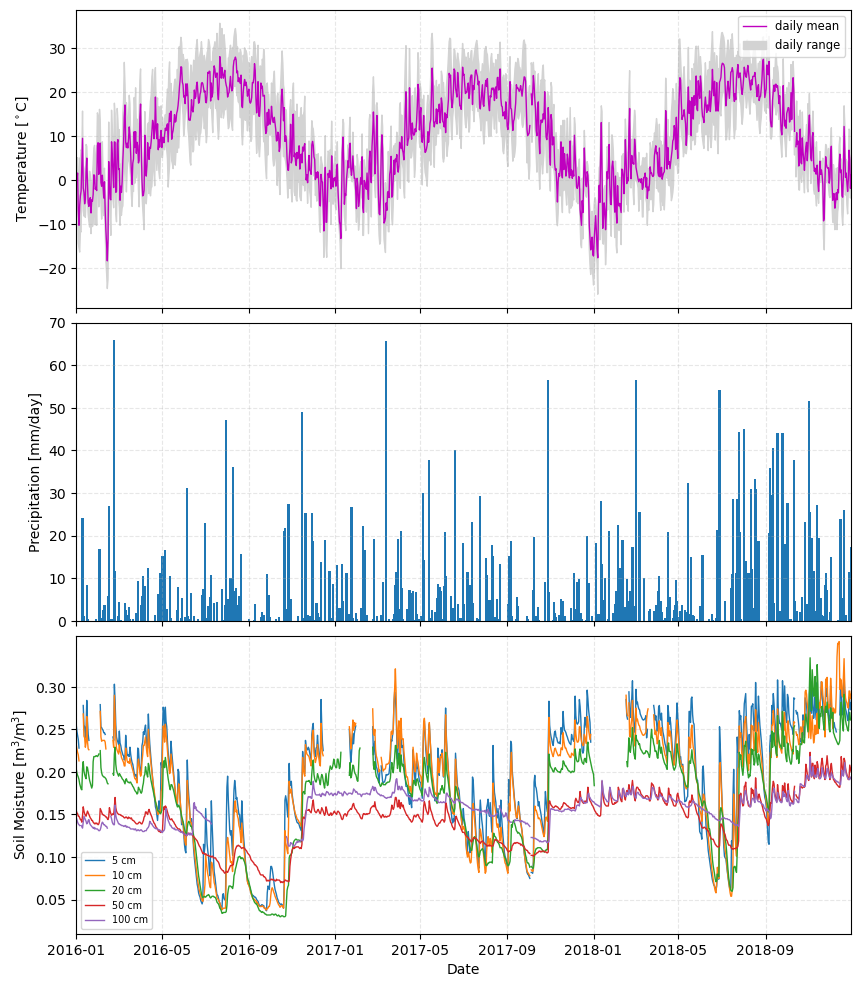

In [151]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plt.subplots_adjust(hspace=0.05)

# Temperature
ax1.plot(date, t_daily_mean, color='m', linewidth=1, label='daily mean')
ax1.fill_between(date, t_daily_min, t_daily_max, color='lightgrey', label='daily range')

ax1.set_ylabel('Temperature [$^\circ$C]')

ax1.legend(loc='upper right', fontsize='small', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.3)

# Precipitation
ax2.bar(date, p_daily_calc, width=3.0, color='tab:blue')
ax2.set_ylabel('Precipitation [mm/day]')
ax2.set_ylim(0, 70)
ax2.grid(True, linestyle='--', alpha=0.3)

# Soil Moisture
ax3.plot(date, soil_moisture_5, label='5 cm', linewidth=1)
ax3.plot(date, soil_moisture_10, label='10 cm', linewidth=1)
ax3.plot(date, soil_moisture_20, label='20 cm', linewidth=1)
ax3.plot(date, soil_moisture_50, label='50 cm', linewidth=1)
ax3.plot(date, soil_moisture_100, label='100 cm', linewidth=1)

ax3.set_ylabel('Soil Moisture [m$^3$/m$^3$]')
ax3.set_xlabel('Date')
ax3.legend(loc='lower left', fontsize='x-small')

ax3.set_yticks([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ax3.set_ylim(0.01, 0.36) 
ax3.grid(True, linestyle='--', alpha=0.3)

ax3.set_xlim(np.datetime64('2016-01-01'), np.datetime64('2018-12-31'))

plt.show()

## Problem 2: Contour Plots

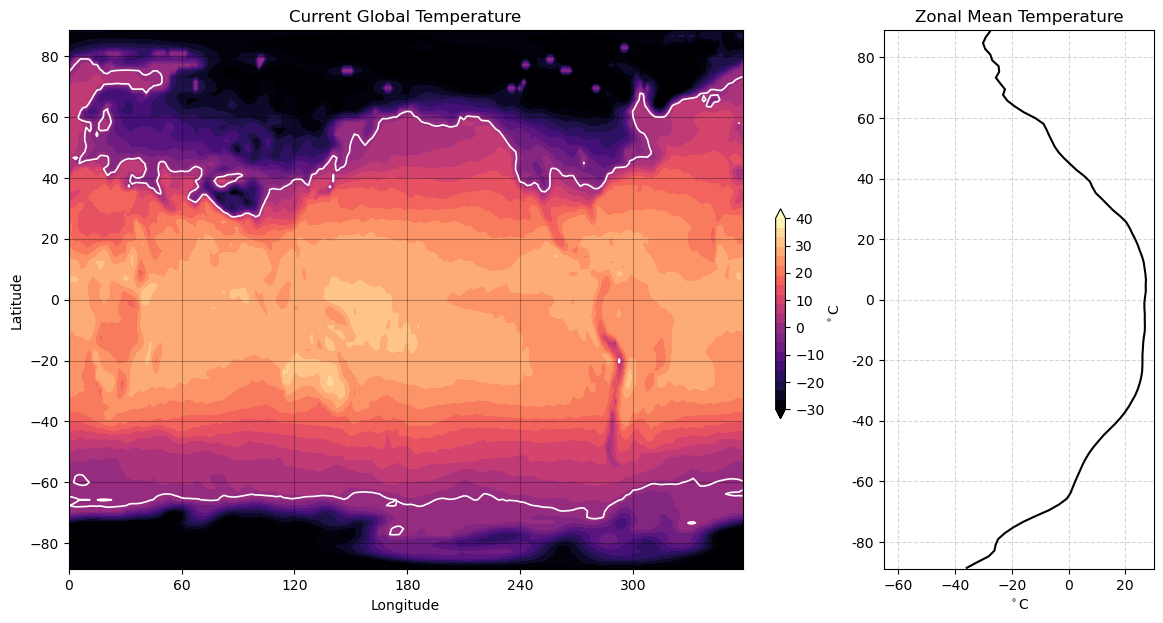

In [227]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), 
                               gridspec_kw={'width_ratios': [2.5, 1], 'wspace': 0.3})

levels = np.linspace(-30, 40, 21)
cf = ax1.contourf(lon, lat, temp, levels=levels, cmap='magma', extend='both')
ax1.contour(lon, lat, temp, levels=[0], colors='white', linewidths=1.2)

ax1.set_title('Current Global Temperature')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_xticks([0, 60, 120, 180, 240, 300])
ax1.set_yticks([-80, -60, -40, -20, 0, 20, 40, 60, 80])
ax1.grid(True, color='black', alpha=0.3)

cax = fig.add_axes([0.63, 0.325, 0.007, 0.30]) 

cbar = fig.colorbar(cf, cax=cax, ticks=np.arange(-30, 41, 10))

cbar.ax.set_ylabel('$^\circ$C', rotation=90, labelpad=3)

zonal_mean = np.mean(temp, axis=1)
ax2.plot(zonal_mean, lat, color='black', linewidth=1.5)

ax2.set_title('Zonal Mean Temperature')
ax2.set_xlim(-65, 30)
ax2.set_xticks([-60, -40, -20, 0, 20])
ax2.set_xlabel('$^\circ$C')
ax2.set_ylim(-89,89)
ax2.set_yticks([-80, -60, -40, -20, 0, 20, 40, 60, 80])
ax2.set_yticklabels([-80, -60, -40, -20, 0, 20, 40, 60, 80])
ax2.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Problem 3: Scatter plots

In [141]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

In [145]:
print(np.isnan(depth).sum())
print(np.isnan(magnitude).sum())

mask = (~np.isnan(depth)) & (~np.isnan(magnitude)) & (depth > 0)

depth = depth[mask]
magnitude = magnitude[mask]
latitude = latitude[mask]
longitude = longitude[mask]

2945
1789


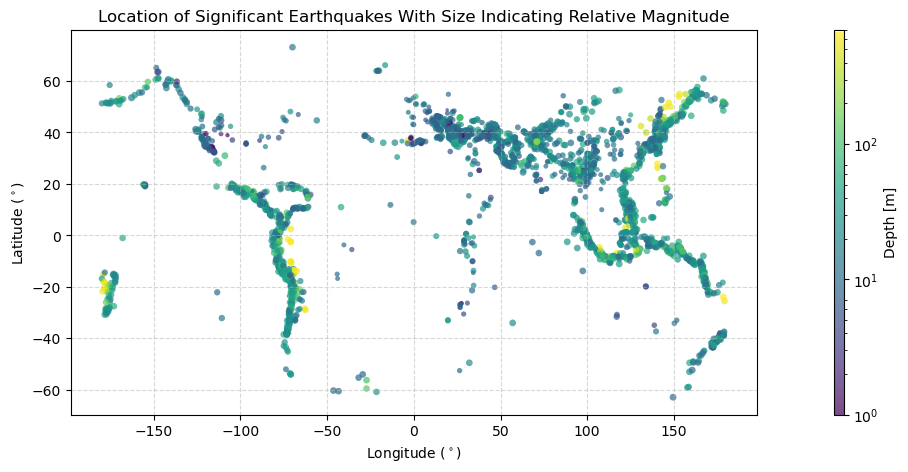

In [222]:
plt.figure(figsize=(10, 5))

sc = plt.scatter(longitude, latitude, s=magnitude*3, c=np.log10(depth), 
                 cmap='viridis', alpha=0.7, edgecolors='none')

cbar = plt.colorbar(sc, fraction=0.015, pad=0.1, aspect=40)
cbar.set_label('Depth [m]')

cbar.set_ticks([0, 1, 2])
cbar.ax.set_yticklabels(['$10^0$', '$10^1$', '$10^2$'])

minor_ticks = [b + np.log10(j) for b in [0, 1, 2] for j in range(2, 8)]
cbar.ax.yaxis.set_ticks(minor_ticks, minor=True)

plt.title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
plt.xlabel('Longitude ($^\circ$)')
plt.ylabel('Latitude ($^\circ$)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()